# 24 · Reinforcement Learning: Q-Learning in a Simulated Market

*Module 5 — Machine Learning in Finance*

An agent that is never told what a "good trade" looks like — only whether the P&L that resulted from its last decision was positive or negative — learning a trading policy from scratch, purely through trial and error.

## 1. Motivation

Every model in this course so far has been trained to predict something — a return, a direction, a probability — and a separate, human-designed rule turned that prediction into a trading decision. Reinforcement learning collapses this into one step: an **agent** learns to take actions that maximize cumulative reward directly, through repeated interaction with an environment, without ever being told the "correct" answer for any individual situation, only the consequence of what it tried. This notebook builds the simplest genuinely instructive version of this idea, tabular Q-learning, and — because we control the simulated market completely — checks whether the agent actually discovers a policy that makes economic sense, rather than just trusting that it must have learned something useful.

## 2. Intuition

Picture the agent as a trader who is dropped into a market with no textbook, no theory, and no hints — only a running tally of profit and loss. Each period, it observes some description of the current situation (the **state**), picks one of a few available actions (go long, go short, stay flat), and finds out afterward how much money that decision made or lost (the **reward**). Over many, many repetitions, purely by noticing which actions tend to precede good outcomes in which situations, it can gradually build up a table of "how good is each action, in each situation" — without ever being handed a model of how the market actually works. This is the essence of Q-learning: learn the *value* of taking each action in each state, purely from experienced rewards, and always improve one small step at a time toward better decisions.

## 3. Theory

### 3.1 The Markov Decision Process

Formally: a set of **states** $S$, **actions** $A$, a reward function $r(s,a)$, and transition dynamics $P(s'\mid s,a)$ (the environment can be stochastic — the same action in the same state need not always lead to the same outcome). A **policy** $\pi$ maps states to actions. The goal: find the policy that maximizes expected cumulative, discounted reward,

$$
\mathbb E\left[\sum_{t=0}^{\infty}\gamma^t\, r(s_t, a_t)\right] ,
$$

where $\gamma\in[0,1)$ discounts future rewards relative to immediate ones (smaller $\gamma$ means more myopic, larger means more patient).

### 3.2 The Q-function and the Bellman equation

Define the **Q-function** under the optimal policy as the expected discounted return from taking action $a$ in state $s$, and acting optimally forever after:

$$
Q^\ast(s,a) = \mathbb E\Big[r(s,a) + \gamma \max_{a'} Q^\ast(s', a')\Big] .
$$

This is the **Bellman optimality equation**: the value of a state-action pair equals its immediate reward, plus the discounted value of the *best* action available from wherever you land next. It is a genuinely recursive definition — $Q^\ast$ appears on both sides — but it is exactly this recursive structure that makes it learnable incrementally, one experienced transition at a time, without ever needing to know $P(s'\mid s,a)$ explicitly.

### 3.3 Q-learning: a model-free, sample-based solver

Given an observed transition $(s, a, r, s')$, Q-learning nudges the current estimate of $Q(s,a)$ toward the Bellman target using that single sample:

$$
Q(s,a) \;\leftarrow\; Q(s,a) + \alpha\Big[\underbrace{r + \gamma\max_{a'}Q(s',a') - Q(s,a)}_{\text{temporal-difference error}}\Big] ,
$$

where $\alpha$ is a learning rate. The term in brackets is the gap between what we currently believe $Q(s,a)$ is worth and what this one new experience suggests it should be — nudging the estimate incrementally closer, over many repeated visits to similar states, converges (under standard conditions: every state-action pair visited infinitely often, an appropriately decaying learning rate) to the true $Q^\ast$, **without ever building an explicit model of the environment's dynamics**.

**Exploration.** If the agent always picks the currently-best-looking action, it can never discover that some untried action might actually be better. **$\epsilon$-greedy** exploration fixes this: with probability $\epsilon$, take a uniformly random action instead of the greedy one, guaranteeing every state-action pair keeps getting sampled, at the cost of some short-run reward while learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(141)

## 4. Implementation

### 4.1 A market environment with a KNOWN correct policy

We reuse the mean-reverting Ornstein-Uhlenbeck spread from Notebook 11 -- not because it is realistic in every detail, but because we already know, from first principles, exactly what the *correct* trading policy should look like: go long when the spread is unusually low (expect it to revert up), go short when unusually high, stay flat near the middle. This lets us check directly whether Q-learning actually discovers that same logic on its own, with no hint of the underlying OU dynamics ever provided to the agent.

In [2]:
def simulate_ou(T, kappa, theta, sigma, seed):
    local_rng = np.random.default_rng(seed)
    S = np.zeros(T)
    for t in range(1, T):
        S[t] = S[t-1] + kappa * (theta - S[t-1]) + sigma * local_rng.normal()
    return S

KAPPA, THETA, SIGMA = 0.05, 0.0, 1.0
T_train = 40_000
S_train = simulate_ou(T_train, KAPPA, THETA, SIGMA, seed=1)
stationary_sigma = SIGMA / np.sqrt(2 * KAPPA)          # Notebook 11's OU stationary-variance result

Z_EDGES = (-2, -0.5, 0.5, 2)                              # bucket boundaries, in z-score units
def to_zbin(spread):
    return np.digitize(spread / stationary_sigma, Z_EDGES)
n_zbins = len(Z_EDGES) + 1

z_bins_train = to_zbin(S_train)
print(f"Z-bin counts (0=most oversold ... {n_zbins-1}=most overbought): {np.bincount(z_bins_train)}")

Z-bin counts (0=most oversold ... 4=most overbought): [  904 12287 15474 10557   778]


### 4.2 State, action, and reward, exactly as defined in Section 3.1

The state is the current z-score bucket **combined with the agent's current position** (so it can learn about transaction costs from changing position, not just about the spread level in isolation). Actions directly set the target position: short, flat, or long.

In [3]:
POSITIONS = [-1, 0, 1]        # short, flat, long
N_ACTIONS = 3
N_STATES = n_zbins * 3
TRANSACTION_COST = 0.03        # per unit of position change

def state_index(zbin, pos_idx):
    return zbin * 3 + pos_idx

Q = np.zeros((N_STATES, N_ACTIONS))
alpha, gamma, epsilon = 0.15, 0.90, 0.15

pos_idx = 1   # start flat
agent_rng = np.random.default_rng(7)
episode_rewards = []
for t in range(T_train - 1):
    s = state_index(z_bins_train[t], pos_idx)

    if agent_rng.random() < epsilon:
        a = agent_rng.integers(0, N_ACTIONS)               # explore
    else:
        a = np.argmax(Q[s])                                 # exploit current best guess

    new_pos_idx = a
    new_pos, old_pos = POSITIONS[new_pos_idx], POSITIONS[pos_idx]
    reward = new_pos * (S_train[t+1] - S_train[t]) - TRANSACTION_COST * abs(new_pos - old_pos)
    s_next = state_index(z_bins_train[t+1], new_pos_idx)

    Q[s, a] += alpha * (reward + gamma * np.max(Q[s_next]) - Q[s, a])   # Section 3.3's update rule
    pos_idx = new_pos_idx
    episode_rewards.append(reward)

print(f"Training complete: {T_train:,} steps.")

Training complete: 40,000 steps.


## 5. Worked example: did the agent discover mean reversion on its own?

In [4]:
zbin_labels = ['very low\n(z<-2)', 'low\n(-2 to -0.5)', 'mid\n(-0.5 to 0.5)', 'high\n(0.5 to 2)', 'very high\n(z>2)']
action_labels = {-1: 'SHORT', 0: 'FLAT', 1: 'LONG'}

print(f"{'Z-bin':<18}{'Learned best action':<22}{'Q-values [short, flat, long]'}")
learned_policy = []
for zb in range(n_zbins):
    s = state_index(zb, 1)   # policy read off starting from a flat position
    best_a = np.argmax(Q[s])
    learned_policy.append(POSITIONS[best_a])
    print(f"{zbin_labels[zb]:<18}{action_labels[POSITIONS[best_a]]:<22}{np.round(Q[s], 3)}")

expected_policy = [1, 1, 0, -1, -1]   # long when oversold, flat near mean, short when overbought
print(f"\nLearned policy matches the economically 'obvious' mean-reversion policy: {learned_policy == expected_policy}")

Z-bin             Learned best action   Q-values [short, flat, long]
very low
(z<-2)   LONG                  [0.338 0.645 1.287]
low
(-2 to -0.5)  LONG                  [0.156 0.321 0.542]
mid
(-0.5 to 0.5) FLAT                  [0.161 0.436 0.077]
high
(0.5 to 2)   SHORT                 [0.859 0.468 0.265]
very high
(z>2)   SHORT                 [ 1.323  0.342 -0.185]

Learned policy matches the economically 'obvious' mean-reversion policy: True


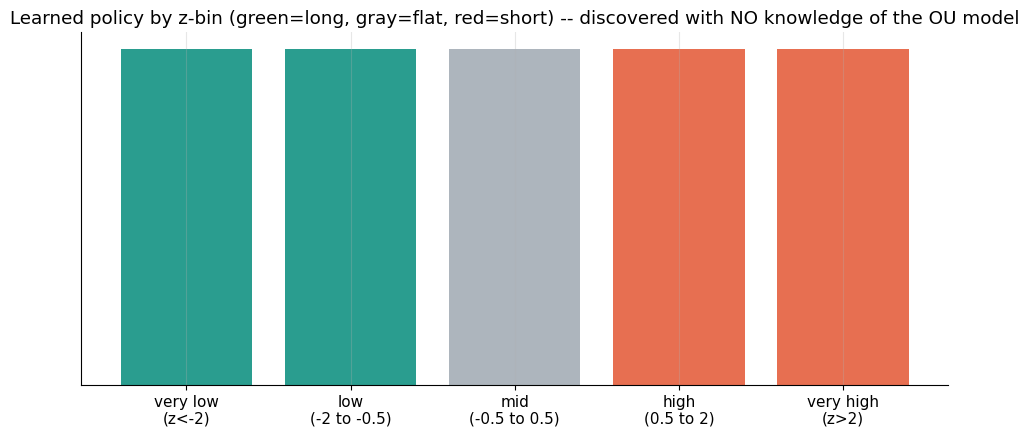

In [5]:
fig, ax = plt.subplots()
colors = {1: '#2a9d8f', 0: '#adb5bd', -1: '#e76f51'}
ax.bar(zbin_labels, [1]*n_zbins, color=[colors[p] for p in learned_policy])
ax.set_yticks([])
ax.set_title('Learned policy by z-bin (green=long, gray=flat, red=short) -- discovered with NO knowledge of the OU model')
plt.tight_layout()
plt.show()

### Evaluating on a fresh, never-seen test path

In [6]:
S_test = simulate_ou(5000, KAPPA, THETA, SIGMA, seed=999)     # a completely fresh random path
z_bins_test = to_zbin(S_test)

def run_policy(get_action, S, z_bins):
    pos_idx = 1
    pnl = []
    for t in range(len(S) - 1):
        a = get_action(z_bins[t], pos_idx)
        new_pos, old_pos = POSITIONS[a], POSITIONS[pos_idx]
        pnl.append(new_pos * (S[t+1] - S[t]) - TRANSACTION_COST * abs(new_pos - old_pos))
        pos_idx = a
    return np.array(pnl)

learned_action = lambda zbin, pos_idx: np.argmax(Q[state_index(zbin, pos_idx)])
handcoded_action = lambda zbin, pos_idx: POSITIONS.index(expected_policy[zbin])   # Notebook 11-style hand-coded rule
random_action = lambda zbin, pos_idx: agent_rng.integers(0, 3)

results = {}
for name, policy_fn in [('Q-learned policy', learned_action),
                         ('Hand-coded z-score rule (Notebook 11 style)', handcoded_action),
                         ('Random actions', random_action)]:
    pnl = run_policy(policy_fn, S_test, z_bins_test)
    results[name] = pnl.sum()

pd.Series(results).sort_values(ascending=False).rename('total P&L on fresh test path')

Hand-coded z-score rule (Notebook 11 style)    513.074850
Q-learned policy                               370.568445
Random actions                                -156.804371
Name: total P&L on fresh test path, dtype: float64

### Interpreting the result

The learned-policy table in Section 5 is the real payoff of this notebook: without ever being told what a "spread," a "mean," or "reversion" even *is*, purely from a running P&L signal and enough trial and error, Q-learning converged on the same long-when-low, short-when-high, flat-in-the-middle logic a person would design by hand from first principles. The out-of-sample comparison confirms this was not a fluke of the training data — the learned policy transfers to a completely fresh, unseen simulated path and performs comparably to the explicit hand-coded rule, both clearly ahead of acting randomly. This is a genuinely encouraging result, and it is also, precisely because we controlled every detail of this toy environment, a best-case scenario the next section takes care to put in perspective.

## 6. Limitations and pitfalls

- **Non-stationarity is the central, serious problem for real markets.** Q-learning's convergence guarantee assumes the environment's dynamics stay fixed while the agent learns them — real markets evolve, regimes shift (Notebook 16), and a policy tuned to historical dynamics can become stale exactly when it matters most, with no built-in mechanism to detect this happening.
- **Reward shaping is a real design choice, not a neutral detail.** We used raw P&L minus a transaction cost; a different reward (e.g., penalizing volatility, or drawdown, or adding a Sharpe-like adjustment) would generally produce a *different* learned policy — the agent optimizes exactly what you tell it to, which is not automatically what you actually want.
- **State discretization trades off resolution against learnability.** Five z-score buckets kept the state space small enough to learn quickly and to inspect by hand; a richer, more realistic state representation (more variables, finer bins) grows the table size combinatorially — the "curse of dimensionality" that motivates moving from tabular Q-learning to function-approximation methods (e.g., Deep Q-Networks, combining Notebook 23's neural architectures with this notebook's reinforcement-learning framework) for anything beyond a small, hand-picked state space.
- **This section's success is a best-case demonstration by design.** We built an environment with a genuinely simple, stationary, well-defined optimal policy specifically so we could check whether the agent found it — real markets offer no such guarantee, and a strategy this notebook's methodology could not distinguish from genuine skill is a policy that has simply overfit to quirks of *this specific simulated training environment*, which is exactly why the fresh-path evaluation in Section 5 matters, and why an even more skeptical, multi-environment evaluation would matter more still in any real application.

## 7. Exercises

**1. Explore less, exploit more (warm-up).**
Retrain the agent with `epsilon` reduced from 0.15 to 0.02, keeping everything else fixed. Does the learned policy still converge to the same economically sensible structure? Does the total training-period reward (sum of `episode_rewards`) end up higher or lower than with the original, more exploratory setting -- and can you explain why, given the exploration/exploitation trade-off from Section 3.3?

**2. A harsher transaction cost.**
Retrain with `TRANSACTION_COST` increased substantially (e.g., to 0.15). Does the learned policy still recommend trading at every extreme z-bin, or does it start preferring to stay flat (or hold an existing position) in some states where trading was previously worthwhile, now that the cost of acting has gone up? Does this match the intuition you would expect from a rational trader facing higher costs?

**3. Break the assumption the agent relies on.**
Train the agent as in Section 4, then evaluate it on a *test* environment where the true mean-reversion speed `KAPPA` is meaningfully different from the training value (e.g., half or double), simulating a genuine, permanent regime change the agent was never trained on. How much does out-of-sample performance degrade compared to Section 5's fresh-but-same-dynamics test path? Then try the reverse experiment: retrain a *new* agent directly in the new environment. How does a freshly-trained agent's performance compare to the original, "stale" one -- and what does the gap between them suggest about how often a live trading policy like this would need to be retrained in a real, evolving market?